# Swiss Roll Benchmark

Evaluates manifold-learning methods on the uniform Swiss roll, against either the **analytic** geodesic (closed-form Riemannian distance on the unrolled spiral) or the **shortest-path** geodesic on a kNN graph (DEMaP convention).

To switch protocols, change `GEODESIC_TYPE` in the configuration cell below. All output paths derive from this flag, so analytic and shortest-path runs do not overwrite each other.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

from utils.benchmark_utils import (
    METHODS, LEVEL1_METHODS,
    METRIC_INFO, DEFAULT_K_TRUST,
    level1_metrics, level2_metrics, fmt, demap,
    get_methods, METHOD_FAMILIES,
    save_synthetic_artifacts,
)
from utils.swiss_roll_utils import (
    make_swiss_roll_with_analytic_geodesic,
    make_swiss_roll_with_shortest_path_geodesic,
)
from utils.plot_config import PLOT_METHODS, PANEL_SIZE, POINT_KWARGS
from utils.helpers import extract_method_distances

import warnings
warnings.filterwarnings("ignore")


## Configuration

**The only line to change** between analytic and shortest-path runs is `GEODESIC_TYPE`. Everything else — output paths, filenames, table labels — is derived automatically.

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# Geodesic protocol — change this to switch between analytic and shortest-path
# ════════════════════════════════════════════════════════════════════════════
GEODESIC_TYPE = "analytic"   # "analytic" or "shortest_path"

# Dataset parameters
N_SAMPLES    = 2000
NOISE        = 0.05
HEIGHT_SCALE = 3.0

# Experiment parameters
N_SEEDS      = 30
SEEDS        = list(range(42, 42 + N_SEEDS))
PLOT_SEED    = SEEDS[0]

# Method / metric parameters
K_TRUST      = 50
K_NN         = 15
K_GEO        = 15      # only used for shortest-path geodesic
k_demap      = 30

EXPORT_LATEX = True


In [3]:
# Output paths — separated by geodesic protocol so runs don't overwrite
TAG = f"uniform_{GEODESIC_TYPE}"
RESULTS_DIR = PROJECT_ROOT / "results" / "swiss_roll" / TAG
FIGURES_DIR = PROJECT_ROOT / "figures" / "swiss_roll" / TAG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geodesic protocol: {GEODESIC_TYPE}")
print(f"Results dir:       {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:       {FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Geodesic protocol: analytic
Results dir:       results/swiss_roll/uniform_analytic
Figures dir:       figures/swiss_roll/uniform_analytic


## Data generator

Wraps the protocol-specific function in a uniform signature, so the rest of the notebook does not need to know which geodesic is in use.

In [4]:
def make_data(seed):
    """Generate Swiss roll with ground-truth geodesic for the current protocol."""
    if GEODESIC_TYPE == "analytic":
        return make_swiss_roll_with_analytic_geodesic(
            n_samples=N_SAMPLES, noise=NOISE,
            random_state=seed, height_scale=HEIGHT_SCALE,
        )
    elif GEODESIC_TYPE == "shortest_path":
        return make_swiss_roll_with_shortest_path_geodesic(
            n_samples=N_SAMPLES, noise=NOISE,
            random_state=seed, height_scale=HEIGHT_SCALE, k_geo=K_GEO,
        )
    else:
        raise ValueError(f"Unknown GEODESIC_TYPE: {GEODESIC_TYPE!r}")


method_names = list(get_methods(0).keys())
print(f"Methods evaluated: {len(method_names)}")
print(method_names)
print(f"\nLevel-1 (distance-fidelity) methods: {LEVEL1_METHODS}")


Methods evaluated: 12
['PCA', 'MDS', 'UMAP', 't-SNE', 'Isomap', 'Shortest Path', 'Laplacian Eigenmaps', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

Level-1 (distance-fidelity) methods: ['Euclidean', 'Isomap', 'Shortest Path', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']


In [5]:
# Result containers
metric_names_l2 = list(METRIC_INFO.keys())
metric_names_l1 = ["spearman_row", "pearson_row",
                   "spearman_global", "pearson_global"]

results_l2 = {
    name: {m: [] for m in metric_names_l2}
    for name in method_names
}
results_l1 = {
    name: {m: [] for m in metric_names_l1}
    for name in LEVEL1_METHODS
}

embeddings_plot    = {}
dist_matrices_plot = {}


## Multi-seed experiment loop

In [6]:
for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")

    X, t, D_geo, X_clean = make_data(seed)
    methods = get_methods(seed=seed, k_nn=K_NN)

    for name, method in methods.items():
        print(f"  {name}")
        try:
            emb = method.fit_transform(X)

            # Level 2 — embedding fidelity against ground-truth geodesic
            m2 = level2_metrics(X, emb, D_geo, k=K_TRUST)
            m2["demap"] = demap(X_clean, emb, knn=k_demap)
            for metric, v in m2.items():
                results_l2[name][metric].append(v)

            # Level 1 — distance matrix fidelity (where exposed)
            D_method = extract_method_distances(method, name)
            if D_method is not None and name in LEVEL1_METHODS:
                m1 = level1_metrics(D_method, D_geo)
                for metric, v in m1.items():
                    results_l1[name][metric].append(v)
                if seed == PLOT_SEED:
                    dist_matrices_plot[name] = D_method

            if seed == PLOT_SEED:
                embeddings_plot[name] = emb

        except Exception as e:
            print(f"    FAILED: {e}")

    # Level 1 Euclidean baseline
    D_eucl = squareform(pdist(X, metric="euclidean"))
    m1 = level1_metrics(D_eucl, D_geo)
    for metric, v in m1.items():
        results_l1["Euclidean"][metric].append(v)
    if seed == PLOT_SEED:
        dist_matrices_plot["Euclidean"] = D_eucl

print("\n=== Done ===")
for name in method_names:
    n = len(results_l2[name]["spearman_row"])
    print(f"  L2 {name:<22s}: {n} seeds")
for name in LEVEL1_METHODS:
    n = len(results_l1[name]["spearman_row"])
    print(f"  L1 {name:<22s}: {n} seeds")



=== Seed 42 ===
  PCA
  MDS
  UMAP


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 43 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 44 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by -1.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 45 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 46 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by 1.3% in final iterations. Consider increasing 

## Results tables

### Level 2 — embedding evaluation

In [7]:
local_metrics  = ["trust", "continuity", "mrre_false", "mrre_missing"]
global_metrics = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global", "demap"]


def build_l2_table(metric_list):
    rows = []
    for name in METHODS:
        s = results_l2.get(name)
        if not s or not s.get("spearman_row"):
            continue
        row = {"Method": name}
        for m in metric_list:
            row[METRIC_INFO[m]] = fmt(s[m])
        rows.append(row)
    return pd.DataFrame(rows).set_index("Method")


df_local  = build_l2_table(local_metrics)
df_global = build_l2_table(global_metrics)

print(f"=== Level 2 — Local metrics ({GEODESIC_TYPE} geodesic) ===")
print(df_local.to_string())
print()
print(f"=== Level 2 — Global metrics ({GEODESIC_TYPE} geodesic) ===")
print(df_global.to_string())

if EXPORT_LATEX:
    print("\n=== LaTeX: local ===")
    print(df_local.to_latex(
        escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_local.columns),
        bold_rows=True,
    ))
    print("\n=== LaTeX: global ===")
    print(df_global.to_latex(
        escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_global.columns),
        bold_rows=True,
    ))


=== Level 2 — Local metrics (analytic geodesic) ===
                    Trustworthiness     Continuity MRRE false (↓) MRRE missing (↓)
Method                                                                            
PCA                   0.941 ± 0.002  0.989 ± 0.000  0.935 ± 0.002    0.991 ± 0.000
MDS                   0.948 ± 0.002  0.987 ± 0.001  0.946 ± 0.002    0.991 ± 0.000
UMAP                  0.994 ± 0.001  0.929 ± 0.005  0.996 ± 0.000    0.976 ± 0.002
t-SNE                 0.992 ± 0.001  0.953 ± 0.004  0.996 ± 0.000    0.979 ± 0.001
Isomap                0.935 ± 0.013  0.958 ± 0.005  0.935 ± 0.014    0.986 ± 0.001
Shortest Path         0.944 ± 0.015  0.956 ± 0.005  0.946 ± 0.016    0.985 ± 0.001
Laplacian Eigenmaps   0.974 ± 0.011  0.938 ± 0.003  0.980 ± 0.011    0.979 ± 0.001
Diffusion Maps        0.979 ± 0.009  0.937 ± 0.003  0.984 ± 0.008    0.979 ± 0.001
PHATE                 0.938 ± 0.011  0.949 ± 0.004  0.947 ± 0.012    0.982 ± 0.001
HeatGeo               0.938 ± 0.012

### Level 1 — distance matrix evaluation

In [8]:
level1_display = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global"]
level1_labels = {
    "spearman_row":    "Spearman (row)",
    "pearson_row":     "Pearson (row)",
    "spearman_global": "Spearman (global)",
    "pearson_global":  "Pearson (global)",
}

rows = []
for name in LEVEL1_METHODS:
    s = results_l1[name]
    if not s["spearman_row"]:
        continue
    row = {"Method": name}
    for m in level1_display:
        row[level1_labels[m]] = fmt(s[m])
    rows.append(row)

df_l1 = pd.DataFrame(rows).set_index("Method")
print(f"=== Level 1 — Distance matrix evaluation ({GEODESIC_TYPE} geodesic) ===")
print(df_l1.to_string())
print()
print(df_l1.to_latex(escape=False, float_format="%.3f",
                     column_format="l" + "c" * len(df_l1.columns)))


=== Level 1 — Distance matrix evaluation (analytic geodesic) ===
               Spearman (row)  Pearson (row) Spearman (global) Pearson (global)
Method                                                                         
Euclidean       0.528 ± 0.008  0.537 ± 0.008     0.510 ± 0.009    0.515 ± 0.009
Isomap          0.829 ± 0.032  0.827 ± 0.033     0.810 ± 0.039    0.782 ± 0.040
Shortest Path   0.829 ± 0.032  0.827 ± 0.033     0.810 ± 0.039    0.782 ± 0.040
Diffusion Maps  0.499 ± 0.016  0.537 ± 0.009     0.488 ± 0.017    0.525 ± 0.014
PHATE           0.806 ± 0.029  0.804 ± 0.029     0.764 ± 0.037    0.739 ± 0.033
HeatGeo         0.791 ± 0.027  0.786 ± 0.029     0.753 ± 0.034    0.724 ± 0.035
DTNE            0.833 ± 0.040  0.823 ± 0.038     0.800 ± 0.050    0.771 ± 0.047
EntroPath       0.877 ± 0.023  0.864 ± 0.025     0.852 ± 0.031    0.810 ± 0.038

\begin{tabular}{lcccc}
\toprule
 & Spearman (row) & Pearson (row) & Spearman (global) & Pearson (global) \\
Method &  &  &  &  \\
\mid

### Correlation gap (Level 1 → Level 2)

How much rank correlation is lost in the MDS embedding step?

In [9]:
print(f"=== Correlation gap ({GEODESIC_TYPE} geodesic) ===")
print(f"{'Method':<18} {'L1 Spearman':>14} {'L2 Spearman':>14} {'Gap':>8}")
print("-" * 58)
for name in LEVEL1_METHODS:
    if name == "Euclidean" or name not in results_l2:
        continue
    if not results_l1[name]["spearman_row"]:
        continue
    if not results_l2[name]["spearman_row"]:
        continue
    l1  = np.mean(results_l1[name]["spearman_row"])
    l2  = np.mean(results_l2[name]["spearman_row"])
    gap = l1 - l2
    print(f"{name:<18} {l1:>14.3f} {l2:>14.3f} {gap:>8.3f}")


=== Correlation gap (analytic geodesic) ===
Method                L1 Spearman    L2 Spearman      Gap
----------------------------------------------------------
Isomap                      0.829          0.777    0.053
Shortest Path               0.829          0.810    0.019
Diffusion Maps              0.499          0.903   -0.404
PHATE                       0.806          0.802    0.005
HeatGeo                     0.791          0.769    0.022
DTNE                        0.833          0.829    0.004
EntroPath                   0.877          0.879   -0.002


## Save results

In [10]:
import json


def _serialise(store):
    out = {}
    for name, metrics in store.items():
        if not any(metrics.values()):
            continue
        out[name] = {
            m: {"mean": float(np.mean(v)),
                "std":  float(np.std(v)),
                "n":    len(v)}
            for m, v in metrics.items() if v
        }
    return out


l2_path = RESULTS_DIR / f"swiss_roll_{TAG}_level2.json"
l1_path = RESULTS_DIR / f"swiss_roll_{TAG}_level1.json"

with open(l2_path, "w") as f:
    json.dump(_serialise(results_l2), f, indent=2)
with open(l1_path, "w") as f:
    json.dump(_serialise(results_l1), f, indent=2)

print(f"Level 2 saved to {l2_path.relative_to(PROJECT_ROOT)}")
print(f"Level 1 saved to {l1_path.relative_to(PROJECT_ROOT)}")


Level 2 saved to results/swiss_roll/uniform_analytic/swiss_roll_uniform_analytic_level2.json
Level 1 saved to results/swiss_roll/uniform_analytic/swiss_roll_uniform_analytic_level1.json


## Plots

### Embedding row (input + selected methods)

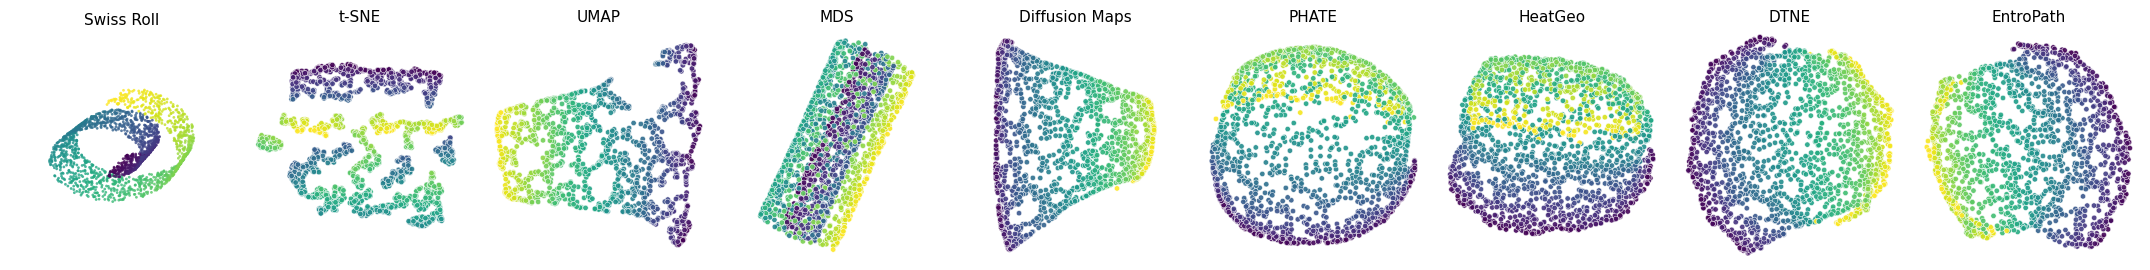

In [11]:
X_plot, t_plot, D_geo_plot, X_clean_plot = make_data(PLOT_SEED)

n_panels = 1 + len(PLOT_METHODS)
PANEL = 2.4
fig, axes = plt.subplots(1, n_panels,
                         figsize=(PANEL * n_panels, PANEL + 0.4))

norm = plt.Normalize(t_plot.min(), t_plot.max())
POINT_KWARGS = dict(s=15, alpha=0.9, linewidths=0.4,
                    edgecolors="white", rasterized=True)

# 3D input panel
axes[0].remove()
ax3d = fig.add_subplot(1, n_panels, 1, projection="3d")
ax3d.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2],
             c=t_plot, cmap="viridis", norm=norm,
             s=4, alpha=0.8, linewidths=0, rasterized=True)
ax3d.set_title("Swiss Roll", fontsize=11, pad=6)
ax3d.set_axis_off()
ax3d.view_init(elev=10, azim=-80)

# 2D method panels
for idx, name in enumerate(PLOT_METHODS, start=1):
    ax = axes[idx]
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        ax.scatter(emb[:, 0], emb[:, 1],
                   c=t_plot, cmap="viridis", norm=norm,
                   **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{TAG}_row.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"{TAG}_row.png", dpi=300, bbox_inches="tight")
plt.show()


### Embedding grid (all methods)

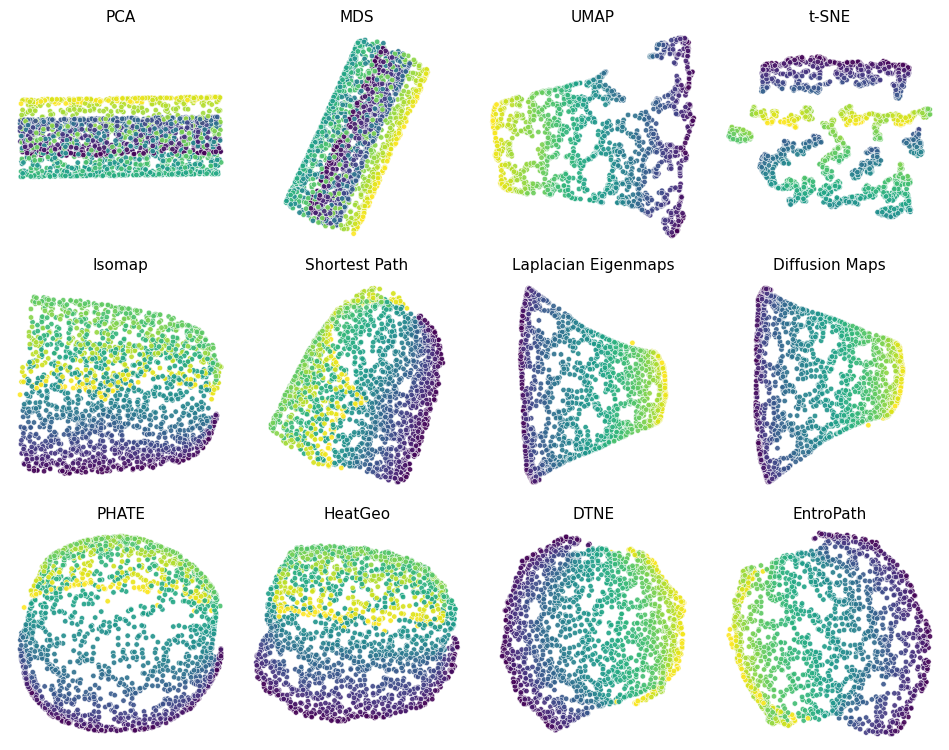

In [12]:
n_cols = 4
n_rows = -(-len(METHODS) // n_cols)   # ceil

PANEL = 2.4
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(PANEL * n_cols, PANEL * n_rows + 0.4))
axes = axes.flatten()

for ax, name in zip(axes, METHODS):
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        ax.scatter(emb[:, 0], emb[:, 1],
                   c=t_plot, cmap="viridis", norm=norm,
                   **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

for ax in axes[len(METHODS):]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig(FIGURES_DIR / f"embeddings_grid_{TAG}.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"embeddings_grid_{TAG}.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Save artifacts

In [13]:
save_synthetic_artifacts(
    embeddings_plot, {}, X_clean_plot, X_plot, t_plot,
    D_geo_plot, level2_results=None,
    config={"plot_seed": PLOT_SEED, "tag": TAG, "n_samples": N_SAMPLES,
            "noise": NOISE, "geodesic_type": GEODESIC_TYPE},
    results_dir=RESULTS_DIR, basename=f"swiss_roll_{TAG}",
)

PosixPath('/Users/przemyslawrola/Desktop/EntroPath/results/swiss_roll/uniform_analytic/swiss_roll_uniform_analytic_artifacts.pkl')

### Shepard diagram

Method distances vs ground-truth geodesic.

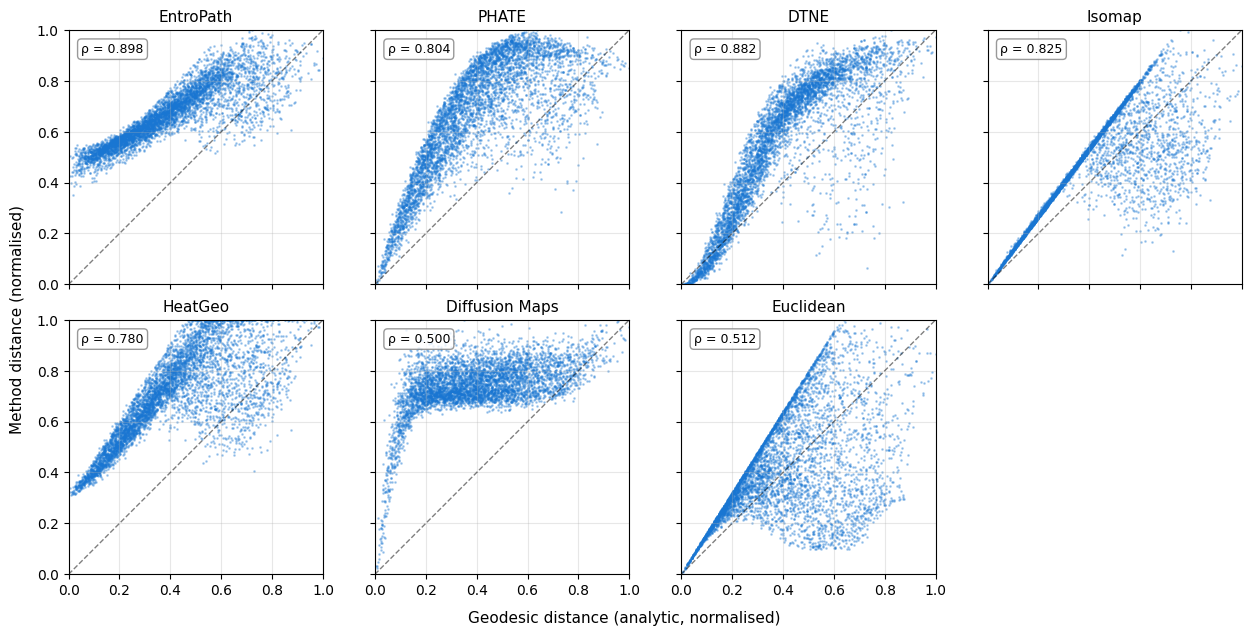

In [14]:
PLOT_DIST_METHODS = ["EntroPath", "PHATE", "DTNE", "Isomap",
                     "HeatGeo", "Diffusion Maps", "Euclidean"]

# Subsample pairs for plotting clarity
n     = D_geo_plot.shape[0]
upper = np.triu_indices(n, k=1)
rng   = np.random.default_rng(42)
idx   = rng.choice(len(upper[0]), size=min(5000, len(upper[0])), replace=False)
rows_, cols_ = upper[0][idx], upper[1][idx]
geo_vals = D_geo_plot[rows_, cols_]
geo_norm = geo_vals / geo_vals.max()

methods_to_plot = [m for m in PLOT_DIST_METHODS if m in dist_matrices_plot]
n_methods = len(methods_to_plot)

ncols = 4
nrows = -(-n_methods // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(3.2 * ncols, 3.2 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, name in zip(axes, methods_to_plot):
    D_method    = dist_matrices_plot[name]
    method_vals = D_method[rows_, cols_]
    method_norm = method_vals / method_vals.max()

    ax.scatter(geo_norm, method_norm,
               s=1, alpha=0.3, rasterized=True, color="#1976D2")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)

    rho, _ = spearmanr(geo_vals, method_vals)
    ax.text(0.05, 0.95, f"ρ = {rho:.3f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white",
                      alpha=0.8, edgecolor="gray"))

    ax.set_title(name, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

for ax in axes[n_methods:]:
    ax.set_visible(False)

fig.supxlabel(f"Geodesic distance ({GEODESIC_TYPE}, normalised)",
              fontsize=11, y=0.02)
fig.supylabel("Method distance (normalised)", fontsize=11, x=0.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_shepard.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_shepard.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Box plots — Level 2 (embedding evaluation)

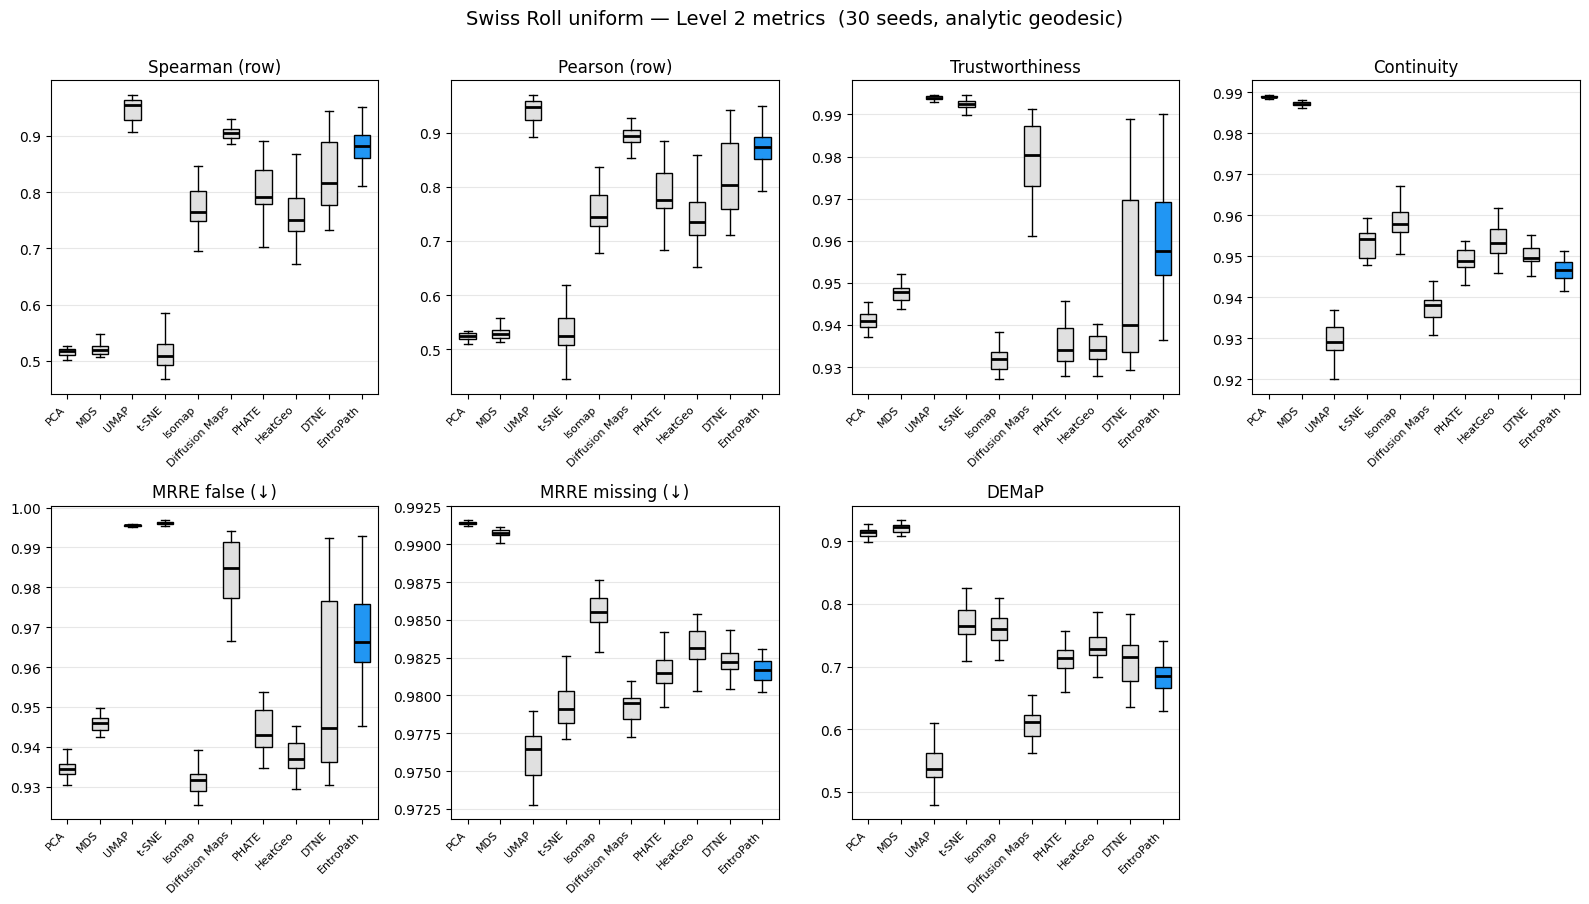

In [15]:
main_metrics = ["spearman_row", "pearson_row", "trust", "continuity",
                "mrre_false", "mrre_missing", "demap"]

BOXPLOT_METHODS = [
    "PCA", "MDS", "UMAP", "t-SNE",
    "Isomap", "Diffusion Maps",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]
plot_names = [n for n in BOXPLOT_METHODS
              if n in results_l2 and results_l2[n].get("spearman_row")]

ncols = 4
nrows = -(-len(main_metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, main_metrics):
    data = [results_l2[n][metric] for n in plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

for ax in axes[len(main_metrics):]:
    ax.set_visible(False)

plt.suptitle(
    f"Swiss Roll uniform — Level 2 metrics  "
    f"({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.00,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_boxplots_l2.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_boxplots_l2.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [16]:
# Median summary — quick reality check
summary = pd.DataFrame({
    METRIC_INFO[m]: {n: np.median(results_l2[n][m])
                     for n in BOXPLOT_METHODS
                     if n in results_l2 and results_l2[n].get(m)}
    for m in main_metrics
})
print(f"=== Median summary ({GEODESIC_TYPE} geodesic) ===")
print(summary.round(3))


=== Median summary (analytic geodesic) ===
                Spearman (row)  Pearson (row)  Trustworthiness  Continuity  \
PCA                      0.517          0.524            0.941       0.989   
MDS                      0.520          0.529            0.948       0.987   
UMAP                     0.955          0.947            0.994       0.929   
t-SNE                    0.509          0.524            0.992       0.954   
Isomap                   0.765          0.744            0.932       0.958   
Diffusion Maps           0.905          0.895            0.980       0.938   
PHATE                    0.792          0.776            0.934       0.949   
HeatGeo                  0.750          0.735            0.934       0.953   
DTNE                     0.816          0.802            0.940       0.950   
EntroPath                0.882          0.874            0.957       0.947   

                MRRE false (↓)  MRRE missing (↓)  DEMaP  
PCA                      0.934          

### Box plots — Level 1 (distance matrix evaluation)

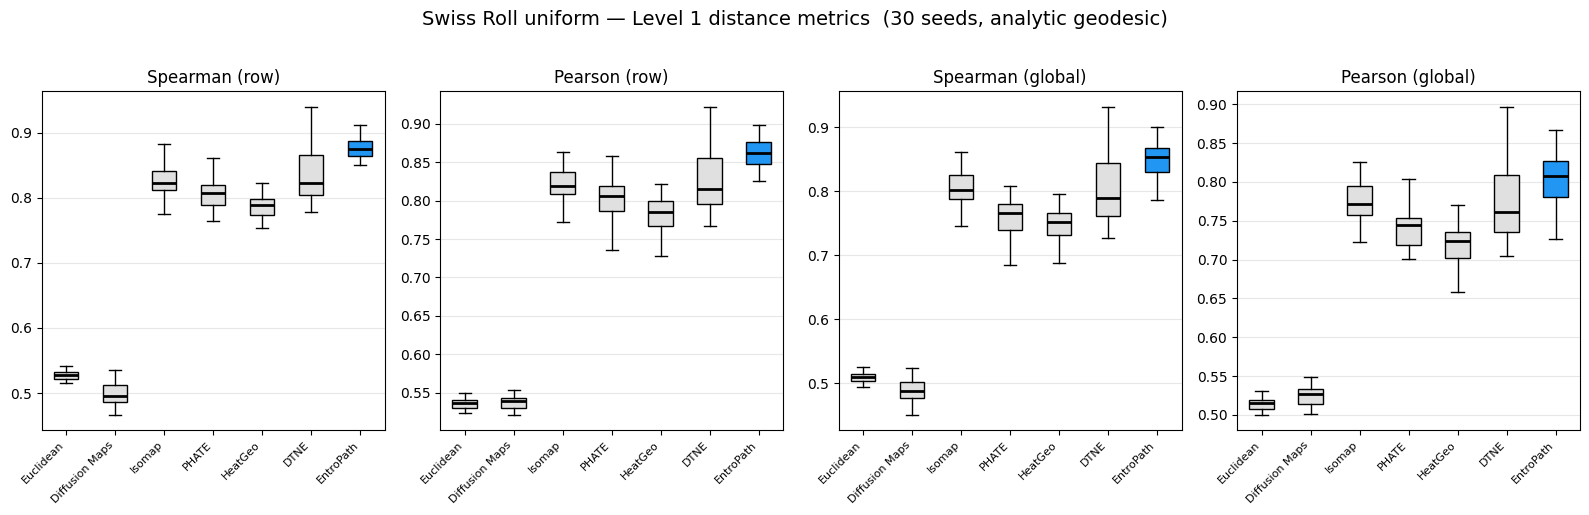

In [17]:
l1_metrics = ["spearman_row", "pearson_row",
              "spearman_global", "pearson_global"]

BOXPLOT_METHODS_L1 = [
    "Euclidean", "Diffusion Maps", "Isomap",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]
l1_plot_names = [n for n in BOXPLOT_METHODS_L1
                 if n in results_l1 and results_l1[n].get("spearman_row")]

fig, axes = plt.subplots(1, len(l1_metrics),
                         figsize=(4 * len(l1_metrics), 5))

for ax, metric in zip(axes, l1_metrics):
    data = [results_l1[n][metric] for n in l1_plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in l1_plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(l1_plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(
    f"Swiss Roll uniform — Level 1 distance metrics  "
    f"({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_boxplots_l1.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_boxplots_l1.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Stability across seeds (geodesic-family methods)

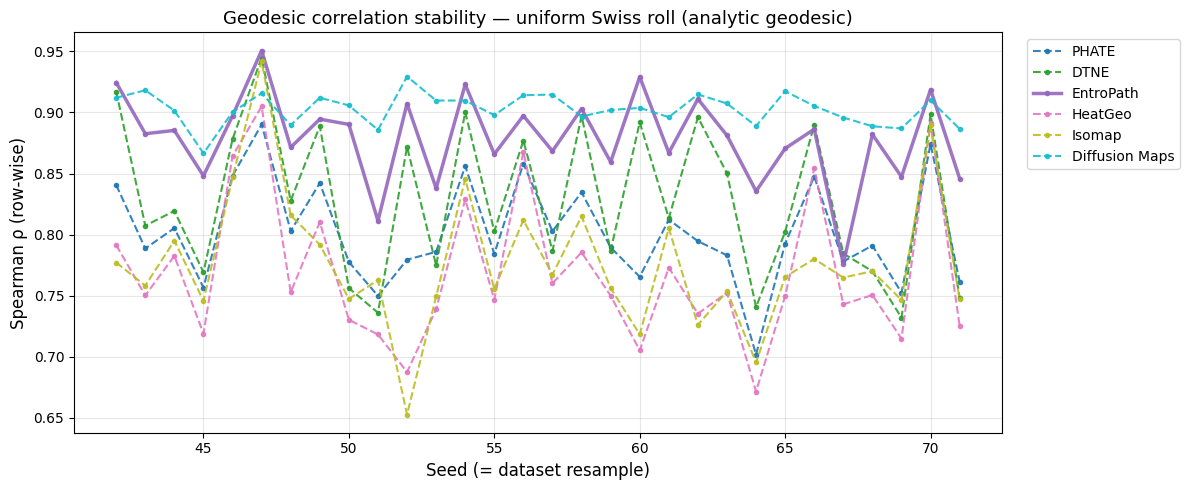

In [18]:
stability_methods = ["PHATE", "DTNE", "EntroPath", "HeatGeo",
                     "Isomap", "Diffusion Maps"]
plot_methods_names = [n for n in stability_methods
                      if n in results_l2 and results_l2[n].get("spearman_row")]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_methods_names)))

for name, color in zip(plot_methods_names, colors):
    vals = results_l2[name]["spearman_row"]
    ls   = "-" if name == "EntroPath" else "--"
    lw   = 2.5 if name == "EntroPath" else 1.5
    ax.plot(
        SEEDS[:len(vals)], vals,
        marker="o", markersize=3,
        color=color, label=name,
        linewidth=lw, linestyle=ls, alpha=0.9,
    )

ax.set_xlabel("Seed (= dataset resample)", fontsize=12)
ax.set_ylabel("Spearman ρ (row-wise)", fontsize=12)
ax.set_title(
    f"Geodesic correlation stability — uniform Swiss roll "
    f"({GEODESIC_TYPE} geodesic)",
    fontsize=13,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_stability.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"swiss_roll_{TAG}_stability.png",
            dpi=300, bbox_inches="tight")
plt.show()
